<a href="https://colab.research.google.com/github/Peeyusj/FashionMNIST/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [5]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.7MB/s]


In [6]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size,shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [9]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [30]:
train(train_dataloader, model, loss_fn, optimizer)

loss: 0.985375  [   64/60000]
loss: 0.977651  [ 6464/60000]
loss: 0.943132  [12864/60000]
loss: 1.088972  [19264/60000]
loss: 0.925675  [25664/60000]
loss: 0.941731  [32064/60000]
loss: 1.016922  [38464/60000]
loss: 0.979733  [44864/60000]
loss: 1.053639  [51264/60000]
loss: 0.988135  [57664/60000]


In [11]:
def test(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.eval()
    correct = 0
    with torch.no_grad():
      for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        correct += (pred.argmax(1) == y).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%")

In [12]:
for epoch in range(15):
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn, optimizer)

loss: 2.167522  [   64/60000]
loss: 2.129324  [ 6464/60000]
loss: 2.099656  [12864/60000]
loss: 2.084584  [19264/60000]
loss: 2.055302  [25664/60000]
loss: 2.038533  [32064/60000]
loss: 2.004527  [38464/60000]
loss: 1.979840  [44864/60000]
loss: 1.911435  [51264/60000]
loss: 1.951419  [57664/60000]
loss: 1.901903  [   64/10000]
loss: 1.896359  [ 6464/10000]
Test Accuracy: 56.8%
loss: 1.892091  [   64/60000]
loss: 1.867602  [ 6464/60000]
loss: 1.774362  [12864/60000]
loss: 1.730767  [19264/60000]
loss: 1.717594  [25664/60000]
loss: 1.680154  [32064/60000]
loss: 1.661284  [38464/60000]
loss: 1.564890  [44864/60000]
loss: 1.543774  [51264/60000]
loss: 1.629145  [57664/60000]
loss: 1.522986  [   64/10000]
loss: 1.544513  [ 6464/10000]
Test Accuracy: 60.7%
loss: 1.585264  [   64/60000]
loss: 1.443111  [ 6464/60000]
loss: 1.371858  [12864/60000]
loss: 1.346855  [19264/60000]
loss: 1.479481  [25664/60000]
loss: 1.373708  [32064/60000]
loss: 1.356860  [38464/60000]
loss: 1.410647  [44864/60000

In [13]:
torch.save(model.state_dict(), "fashion_classifier.pth")

In [32]:
from PIL import Image
img = Image.open("item2.png")
print(img.size, img.mode)

(485, 483) RGB


Bag


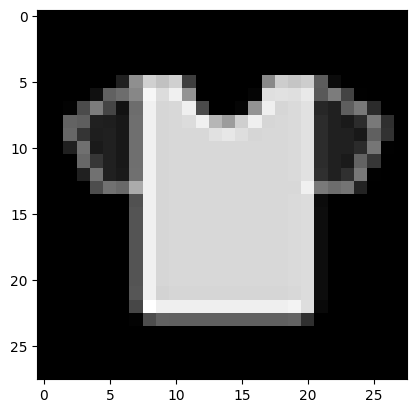

RGB
Bag 17.2%
Shirt 14.6%
Coat 13.8%


In [33]:
from PIL import Image, ImageOps
from torchvision import transforms

classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

img = Image.open("item2.png").convert("L")   # make it black and white
img = ImageOps.invert(img)
img = img.resize((28, 28))                  # shrink to 28x28
x = transforms.ToTensor()(img)              # turn it into numbers
x = x.unsqueeze(0).to(device)               # wrap it as a batch of 1

model.eval()
with torch.no_grad():
    pred = model(x)

print(classes[pred.argmax(1).item()])
import matplotlib.pyplot as plt
plt.imshow(x.squeeze().cpu(), cmap="gray")
plt.show()
print(Image.open("item2.png").mode)
probs = torch.softmax(pred, dim=1)[0]
for i in probs.argsort(descending=True)[:3]:
    print(classes[i], f"{probs[i].item()*100:.1f}%")